In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("des_results.csv")

In [75]:
#Some basic checks on the final DataFrame:

print(df.shape)

df.head(10)


(230, 14)


,SNID,Redshift CMB,Stretch factor,Phillips parameter,Decay time,x1,x1_err,t0,t0_err,c,c_err,Fit success,MJD MIN,MJD MAX
0,1259412,0.304774,1.066169,0.942049,15.992539,0.925221,0.055109,56624.285133,0.075835,-0.019795,0.004315,True,56564.267,56916.271
1,1336002,0.394970,1.046499,0.975206,15.697489,0.716856,0.215201,57353.023984,0.202496,0.018239,0.019572,True,57297.030,57407.048
2,1337687,0.328699,1.072738,0.931028,16.091072,0.994598,0.128927,57361.393704,0.169856,-0.094012,0.009019,True,57298.353,57425.154
3,1248907,0.170534,1.021140,1.018400,15.317105,0.446259,0.042668,56548.203990,0.033722,-0.009405,0.003476,True,56534.154,56697.058
4,1303279,0.172738,1.032630,0.998758,15.489445,0.569187,0.081162,56965.737944,0.070926,-0.089824,0.006497,True,56912.344,57255.417
5,1292560,0.224823,1.015712,1.027728,15.235673,0.387954,0.103613,56904.637984,0.157079,-0.096860,0.009614,True,56890.263,57051.057
6,1308884,0.076584,0.849773,1.341369,12.746601,-1.539223,0.013028,57293.549744,0.011760,0.095921,0.002200,True,57249.403,57426.118
7,1298893,0.196163,0.775242,1.524280,11.628624,-2.627030,0.206207,56935.755267,0.209151,-0.011302,0.019502,True,56887.268,57052.042
8,1341894,0.312943,0.964413,1.117781,14.466192,-0.172309,0.259431,57390.065268,0.242608,-0.015989,0.016393,True,57339.033,57427.057
9,1346137,0.363263,1.071177,0.933644,16.067662,0.978123,0.424963,57403.287101,0.455844,0.056005,0.020209,True,57355.238,57425.153


In [76]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SNID                230 non-null    int64  
 1   Redshift CMB        230 non-null    float64
 2   Stretch factor      230 non-null    float64
 3   Phillips parameter  230 non-null    float64
 4   Decay time          230 non-null    float64
 5   x1                  230 non-null    float64
 6   x1_err              230 non-null    float64
 7   t0                  230 non-null    float64
 8   t0_err              230 non-null    float64
 9   c                   230 non-null    float64
 10  c_err               230 non-null    float64
 11  Fit success         230 non-null    bool   
 12  MJD MIN             230 non-null    float64
 13  MJD MAX             230 non-null    float64
dtypes: bool(1), float64(12), int64(1)
memory usage: 23.7 KB


In [77]:
df.describe()

,SNID,Redshift CMB,Stretch factor,Phillips parameter,Decay time,x1,x1_err,t0,t0_err,c,c_err,MJD MIN,MJD MAX
count,2.300000e+02,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000
mean,1.310552e+06,0.377521,0.987185,1.084363,14.807770,0.043340,0.281982,57146.588020,0.313075,0.006006,0.019530,57097.439130,57294.307004
std,2.594296e+04,0.165362,0.087756,0.161950,1.316343,1.000341,0.208296,243.500632,0.268707,0.090576,0.014175,246.877135,190.097813
min,1.248677e+06,0.059629,0.760543,0.659199,11.408144,-2.883202,0.013028,56548.203990,0.000001,-0.231446,0.002200,56534.154000,56693.042000
25%,1.292750e+06,0.249272,0.936710,0.970385,14.050655,-0.484382,0.116497,56959.935112,0.120870,-0.063336,0.009410,56904.236250,57253.818000
50%,1.309122e+06,0.349674,0.993235,1.066718,14.898529,0.144776,0.230781,57276.879544,0.224015,-0.006544,0.014731,57248.404500,57407.048000
75%,1.334874e+06,0.489156,1.049350,1.168305,15.740257,0.747125,0.408088,57342.565962,0.440184,0.067364,0.025735,57287.187500,57426.147000
max,1.347120e+06,0.848519,1.234555,1.568118,18.518318,2.719251,0.984151,57411.971831,1.830811,0.257064,0.088421,57356.168000,57428.056000


In [78]:
# Finding the mean of the Rest-frame Decay time (T_rest) in the DataFrame

c = df["Decay time"].mean()

c_err = df["Decay time"].sem()

print(f"Mean Rest-frame Decay time: {c:.2f} ± {c_err:.2f}")

Mean Rest-frame Decay time: 14.81 ± 0.09


In [79]:
# Modeling using Curve fitting

from scipy.optimize import curve_fit

c = 14.81 

xdata = np.array(df["Redshift CMB"])
ydata = np.array(df["Decay time"])

def model_equation(z, b):
	return c * (1+z)**b

popt, pcov = curve_fit(model_equation, xdata, ydata)

b = popt[0]
b_err = np.sqrt(pcov[0,0])

print(f"b = {b} ± {b_err}")

b = 0.00884106713936769 ± 0.017440301646945773


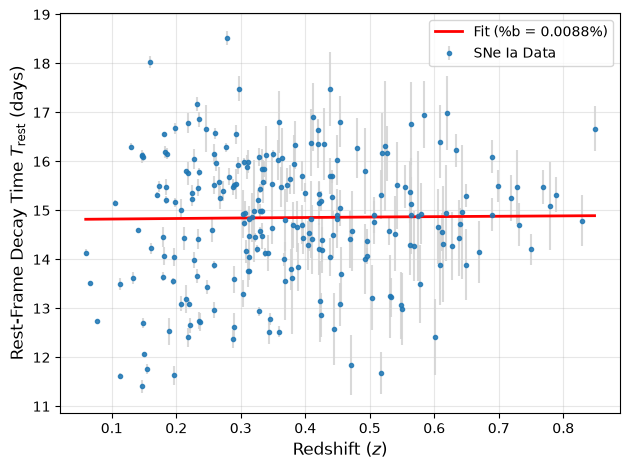

In [80]:
# Figure 1 - Rest-frame Decay time (T_rest) vs Redshift (z), along with the error bars and the best fit of the curve fitting 

der = 0.091 + (0.006 * df["x1"]) - (0.00225 * df["x1"]**2)

yerr_data = 15 * np.abs(der) * df["x1_err"] 

sort_idx = np.argsort(xdata)

plt.errorbar(xdata, ydata, yerr = yerr_data, fmt = "o", markersize = 3, ecolor = "lightgray", alpha = 0.85, label = "SNe Ia Data")

plt.plot(xdata[sort_idx], model_equation(xdata[sort_idx], b), color = "red", linewidth = 2, label = f"Fit (%b = {b:.4f}%)")

plt.xlabel("Redshift ($z$)", fontsize = 12)
plt.ylabel("Rest-Frame Decay Time $T_{\\rm rest}$ (days)", fontsize = 12)

plt.grid(True, linestyle = "-", alpha = 0.3)
plt.legend(loc = "upper right", frameon = True)
plt.tight_layout()

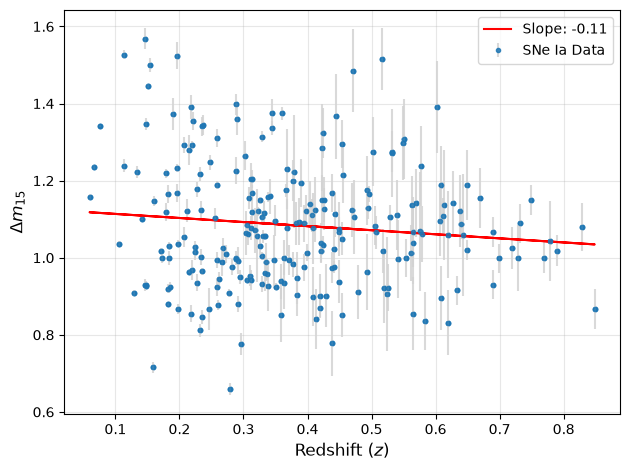

In [81]:
# Figure 2 - Phillips Parameter (m15) vs Redshift (z) along with the error bars and linear slope

x, y = df["Redshift CMB"], df["Phillips parameter"]

plt.scatter(df["Redshift CMB"], df["Phillips parameter"], linewidth = 2, s = 5)

m, b = np.polyfit(x, y, deg = 1)

der = -0.161 + (0.0026 * df["x1"]) - (0.00039 * df["x1"]**2)

dm15_err = np.abs(der) * df["x1_err"]

plt.errorbar(x, y, yerr = dm15_err, fmt = "o", markersize = 3, ecolor = "lightgray", alpha = 0.85, label = "SNe Ia Data")

plt.plot(x, m * x + b, color = "red", label = f"Slope: {m:.2f}")

plt.xlabel("Redshift ($z$)", fontsize = 12)
plt.ylabel("$\\Delta m_{15}$", fontsize = 12)
plt.grid(True, linestyle = "-", alpha = 0.3)
plt.legend(loc = "upper right", frameon = True)
plt.tight_layout()